# Network Analysis EDA

## Setup

In [1]:
# Import Packages
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import community
from networkx.algorithms import bipartite as nxb
from collections import Counter
from itertools import combinations
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import re
import math
from networkx.algorithms.community import greedy_modularity_communities
from typing import Optional
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("All libraries loaded")

All libraries loaded


In [4]:
df_conv = pd.read_parquet("../data_storage/streamlit_app_data/final_dataset_with_attribution.parquet")

In [5]:
STOP = set(stopwords.words("english"))
LEMM = WordNetLemmatizer()

def preprocess_article_text_nltk(text: str) -> list[str]:
    """
    Lowercase → strip non-letters → tokenize by whitespace → remove stopwords/short tokens → lemmatize (noun).
    Keeps it lightweight for Python 3.13 compatibility (no POS tag requirement).
    """
    if not isinstance(text, str) or not text:
        return []
    txt = text.lower()
    txt = re.sub(r"[^a-z\s]", " ", txt)     
    toks = [t for t in txt.split() if len(t) > 2 and t not in STOP]
    
    toks = [LEMM.lemmatize(t) for t in toks]
    return toks

In [6]:
def build_tokens(attDF: pd.DataFrame, body_col: str = "article_body") -> pd.DataFrame:
    if body_col not in attDF.columns:
        raise KeyError(f"Column '{body_col}' not found in DataFrame.")
    out = attDF.copy()
    out["tokens"] = out[body_col].fillna("").apply(preprocess_article_text_nltk)
    out["keyword_counts"] = out["tokens"].apply(lambda toks: Counter(toks))
    return out

df_conv = build_tokens(df_conv, body_col="article_body")

In [7]:
df_conv.head()

,article_body,article_id,author_name,channel_name,circulation_size,feed_name,headline,hit_strength,people_by_row,publication_name,...,people_by_row_clean,headline_token_count,body_token_count,token_count,emotion_body,seq_index,circulation_size_bin,sentiment_score_bin,tokens,keyword_counts
0,juliann ventura hill posted dec cst updated de...,18918986050,juliann_ventura,web,47759,opoint,warren rfk pick say goodbye smile say hello polio,2,"Elizabeth Warren, Juliann Ventura, Robert F Ke...",cw33,...,"Elizabeth Warren, Juliann Ventura, Robert F Ke...",9,329,338,fear,1,4,5,"[juliann, ventura, hill, posted, dec, cst, upd...","{'juliann': 1, 'ventura': 1, 'hill': 2, 'poste..."
1,geneva switzerland may ani health leaders coun...,18284984014,unknown,web,950,opoint,asia pacific countries sound alarm commit tack...,5,"Timor Leste, Vanuatu, Saia Piukala, Shiozaki A...",the_tennis_times,...,"Timor Leste, Vanuatu, Saia Piukala, Shiozaki A...",9,462,471,fear,2,1,5,"[geneva, switzerland, may, ani, health, leader...","{'geneva': 2, 'switzerland': 3, 'may': 1, 'ani..."
2,providing top notch dental care new york city ...,18173606533,unknown,web,1094,opoint,tushin shah dds highly skilled dentist ascent ...,1,Tushin Shah,reporter_pass,...,Tushin Shah,10,282,292,joy,3,2,5,"[providing, top, notch, dental, care, new, yor...","{'providing': 2, 'top': 1, 'notch': 1, 'dental..."
3,navigating global health funding shift priorit...,19446163286,unknown,web,1048,opoint,wha daily update may,8,"Warren Buffett, Senait Fisseha, Tedros Ghebrey...",archynewsy,...,"Warren Buffett, Senait Fisseha, Tedros Ghebrey...",4,1342,1346,fear,4,2,5,"[navigating, global, health, funding, shift, p...","{'navigating': 2, 'global': 34, 'health': 85, ..."
4,midday plans something matter spend antenna ho...,19119220222,unknown,broadcast,954,tveyes,wgn radio midday plans something matter spend ant,1,"Brian, Queen Anne, Samir Va, Mark Ruffalo, Lis...",wgn_am_radio,...,"Brian, Queen Anne, Samir Va, Mark Ruffalo, Lis...",8,377,385,joy,5,1,3,"[midday, plan, something, matter, spend, anten...","{'midday': 1, 'plan': 1, 'something': 1, 'matt..."


In [8]:
### keyword frequency table 
def keyword_frequency_table(attDF: pd.DataFrame, tokens_col: str = "tokens") -> pd.DataFrame:
    if tokens_col not in df_conv.columns:
        raise KeyError(f"Column '{tokens_col}' not found in DataFrame.")
    kw = (df_conv.explode(tokens_col)
            .groupby(tokens_col)
            .size()
            .reset_index(name="frequency")
            .sort_values("frequency", ascending=False)
            .rename(columns={tokens_col: "keyword"}))
    return kw

keywords_df = keyword_frequency_table(df_conv)
display(keywords_df.head(25))

,keyword,frequency
66872,health,309749
138239,said,117510
127305,public,112176
119725,people,94362
42074,disease,88936
175685,year,87861
108294,new,71201
149975,state,71178
5316,also,67444
166725,vaccine,67405


## Analysis

In [11]:
from typing import List, Optional, Union

DF = df_conv
SOURCE_COL = "source_name"
TOPIC_COL  = "tag_name"

WEIGHT_BY = ["circulation_size", "vipr_weight", "hit_strength"]
WEIGHT_WEIGHTS = None   

MIN_EDGE_WEIGHT = 0.2
MIN_TOPICS_PER_SOURCE = 2
MIN_SOURCES_PER_TOPIC = 2
USE_TFIDF = True

EDGE_KEEP_PCT_BIP = 75
EDGE_KEEP_PCT_PROJ = 70
LABEL_SOURCES_TOP = 25
LABEL_TOPICS_TOP = 8

# 1) Rank-only combiner
def _combine_rankpct(
    df: pd.DataFrame,
    cols: List[str],
    weights: Optional[List[float]] = None
) -> pd.Series:
    """
    Percentile-rank each column to [0,1], then take a (weighted) mean across columns.
    Robust to scale/outliers. NaNs are filled with the column's mean rank.
    """
    X = df[cols].copy().replace([np.inf, -np.inf], np.nan)
    R = X.rank(pct=True, na_option="keep")
    R = R.fillna(R.mean())
    if weights is None:
        w = np.ones(len(cols), dtype=float)
    else:
        w = np.asarray(weights, dtype=float)
    s = w.sum()
    if s == 0:
        w = np.ones(len(cols), dtype=float)
        s = w.sum()
    w = w / s
    return (R * w).sum(axis=1)

# 2) Build bipartite graph
def build_source_topic_bipartite(
    df: pd.DataFrame,
    source_col: str = "source_type_name",
    topic_col: str = "tag_name",
    weight_by: Union[str, List[str]] = "count",
    weight_weights: Optional[List[float]] = None,
    min_edge_weight: float = 0.2,
    min_topics_per_source: int = 2,
    min_sources_per_topic: int = 2,
    drop_na: bool = True,
    use_tfidf: bool = False,
    use_sum_instead_of_mean: bool = False
):
    assert source_col in df.columns and topic_col in df.columns, "Missing source/topic columns."
    dd = df.copy()
    if drop_na:
        dd = dd.dropna(subset=[source_col, topic_col])

    # weights
    if isinstance(weight_by, str):
        if weight_by == "count":
            agg = dd.groupby([source_col, topic_col]).size().reset_index(name="weight")
        else:
            if weight_by not in dd.columns:
                raise ValueError(f"weight_by='{weight_by}' not found in DataFrame.")
            agg = dd.groupby([source_col, topic_col])[weight_by].sum(min_count=1).reset_index(name="weight")
    else:
        # list of columns blended via rank-pct
        for c in weight_by:
            if c not in dd.columns:
                raise ValueError(f"Column '{c}' in weight_by not found in DataFrame.")
        dd["__combined_weight__"] = _combine_rankpct(dd, weight_by, weights=weight_weights)
        grp = dd.groupby([source_col, topic_col])["__combined_weight__"]
        agg = (grp.sum() if use_sum_instead_of_mean else grp.mean()).reset_index(name="weight")

    # edge threshold
    agg = agg[agg["weight"] >= min_edge_weight].copy()
    if agg.empty:
        return nx.Graph(), agg, set(), set()

    # optional TF-IDF reweighting
    if use_tfidf:
        src_tot = agg.groupby(source_col)["weight"].transform("sum")
        agg["tf"] = agg["weight"] / src_tot
        topic_src_n = agg.groupby(topic_col)[source_col].transform("nunique")
        n_sources = agg[source_col].nunique()
        agg["idf"] = np.log((n_sources + 1) / (topic_src_n + 1)) + 1
        agg["weight"] = agg["tf"] * agg["idf"]
        agg = agg[[source_col, topic_col, "weight"]]

    # degree pruning
    keep_src = set(agg.groupby(source_col)[topic_col].nunique().pipe(lambda s: s[s >= min_topics_per_source].index))
    keep_top = set(agg.groupby(topic_col)[source_col].nunique().pipe(lambda s: s[s >= min_sources_per_topic].index))
    agg = agg[agg[source_col].isin(keep_src) & agg[topic_col].isin(keep_top)]
    if agg.empty:
        return nx.Graph(), agg, set(), set()

    # build graph
    B = nx.Graph()
    B.add_nodes_from(sorted(keep_src), bipartite=0, kind="source")
    B.add_nodes_from(sorted(keep_top), bipartite=1, kind="topic")
    B.add_weighted_edges_from(agg[[source_col, topic_col, "weight"]].itertuples(index=False, name=None))
    sources = {n for n, d in B.nodes(data=True) if d.get("bipartite") == 0}
    topics  = set(B) - sources
    return B, agg, sources, topics

In [12]:
# 3) Visual helpers
def _safe_bipartite_layout(G, left_nodes):
    try:
        return nxb.layout.bipartite_layout(G, left_nodes)
    except Exception:
        return nx.spring_layout(G, seed=42)

def visualize_bipartite(B, sources, topics, title="Sources ↔ Topics (Bipartite)",
                        label_sources_top=20, label_topics_top=0, edge_keep_pct=70):
    if B.number_of_nodes() == 0:
        print("Graph is empty."); return
    w = np.array([B[u][v].get("weight", 1) for u, v in B.edges()])
    thr = np.percentile(w, 100 - edge_keep_pct) if len(w) else 1
    H = nx.Graph()
    H.add_nodes_from(B.nodes(data=True))
    H.add_edges_from([(u, v, d) for u, v, d in B.edges(data=True) if d.get("weight", 1) >= thr])
    H.remove_nodes_from([n for n in list(H.nodes) if H.degree(n) == 0])
    if H.number_of_nodes() == 0:
        print("No nodes after pruning."); return
    comps = list(nx.connected_components(H))
    H = H.subgraph(max(comps, key=len)).copy()

    left = [n for n in H.nodes if n in sources]
    right = [n for n in H.nodes if n in topics]
    if not left or not right:
        left = [n for n, d in H.nodes(data=True) if d.get("bipartite") == 0] or left
        right = [n for n, d in H.nodes(data=True) if d.get("bipartite") == 1] or right

    pos = _safe_bipartite_layout(H, left)
    strength = {n: sum(H[n][nbr].get("weight", 1) for nbr in H.neighbors(n)) for n in H.nodes()}
    size_map = {n: 80 + 12*np.log1p(s) for n, s in strength.items()}
    ewidths = [0.6 + np.log1p(H[u][v].get("weight", 1)) for u, v in H.edges()]

    plt.figure(figsize=(12, 8))
    nx.draw_networkx_edges(H, pos, width=ewidths, alpha=0.35)
    src_nodes = nx.draw_networkx_nodes(H, pos, nodelist=left, node_color="#3b82f6",
                                       node_size=[size_map[n] for n in left], label="Sources")
    top_nodes = nx.draw_networkx_nodes(H, pos, nodelist=right, node_color="#a78bfa",
                                       node_size=[size_map[n] for n in right], label="Topics")

    degH = dict(H.degree())
    top_src = {n for n, _ in sorted(((n, degH.get(n, 0)) for n in left), key=lambda x: x[1], reverse=True)[:label_sources_top]}
    top_top = {n for n, _ in sorted(((n, degH.get(n, 0)) for n in right), key=lambda x: x[1], reverse=True)[:label_topics_top]}
    nx.draw_networkx_labels(H, pos, labels={n:n for n in (top_src | top_top)}, font_size=8)

    plt.title(title)
    plt.legend(handles=[src_nodes, top_nodes], scatterpoints=1, fontsize=9, frameon=False, loc="upper left")
    plt.axis("off"); plt.tight_layout(); plt.show()

def project_sources(B, sources, method="overlap"):
    if method == "weighted": return nxb.weighted_projected_graph(B, sources, weight="weight")
    if method == "jaccard":  return nxb.jaccard_weighted_projected_graph(B, sources)
    return nxb.overlap_weighted_projected_graph(B, sources, jaccard=False)

def project_topics(B, topics, method="overlap"):
    if method == "weighted": return nxb.weighted_projected_graph(B, topics, weight="weight")
    if method == "jaccard":  return nxb.jaccard_weighted_projected_graph(B, topics)
    return nxb.overlap_weighted_projected_graph(B, topics, jaccard=False)

def visualize_projection(G, title="Projection", label_top=20, edge_keep_pct=70):
    if G.number_of_nodes() == 0:
        print("Projection is empty."); return
    w = np.array([G[u][v].get("weight", 1) for u, v in G.edges()])
    thr = np.percentile(w, 100 - edge_keep_pct) if len(w) else 1
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    H.add_edges_from([(u, v, d) for u, v, d in G.edges(data=True) if d.get("weight", 1) >= thr])
    H.remove_nodes_from([n for n in list(H.nodes) if H.degree(n) == 0])
    if H.number_of_nodes() == 0:
        print("No nodes after pruning."); return
    pos = nx.spring_layout(H, seed=42, k=1/np.sqrt(max(1, H.number_of_nodes())))
    strength = {n: sum(H[n][nbr].get("weight", 1) for nbr in H.neighbors(n)) for n in H.nodes()}
    sizes = [120 + 14*np.log1p(strength[n]) for n in H.nodes()]
    ewidths = [0.6 + np.log1p(H[u][v].get("weight", 1)) for u, v in H.edges()]
    plt.figure(figsize=(11, 8))
    nx.draw_networkx_edges(H, pos, width=ewidths, alpha=0.35)
    nx.draw_networkx_nodes(H, pos, node_size=sizes)
    top_nodes = {n for n, _ in sorted(strength.items(), key=lambda x: x[1], reverse=True)[:label_top]}
    nx.draw_networkx_labels(H, pos, labels={n:n for n in top_nodes}, font_size=9)
    plt.title(title); plt.axis("off"); plt.tight_layout(); plt.show()

[info] SOURCE_COL 'source_name' not found. Using fallback: 'source_type'
edges kept in agg: 56
sources: 14 topics: 5


,source_type,tag_name,weight
28,radio,nhs_reform,0.619525
5,consumer,nhs_reform,0.562622
32,regional_news,nhs_reform,0.549757
50,twitter,state_healthcare_funding,0.502776
2,blog,state_healthcare_funding,0.430138
17,government,world_health_leadership,0.402563
20,national_news,state_healthcare_funding,0.395868
53,video,public_health,0.385940
42,trade_news,state_healthcare_funding,0.382653
54,video,world_health_leadership,0.373591


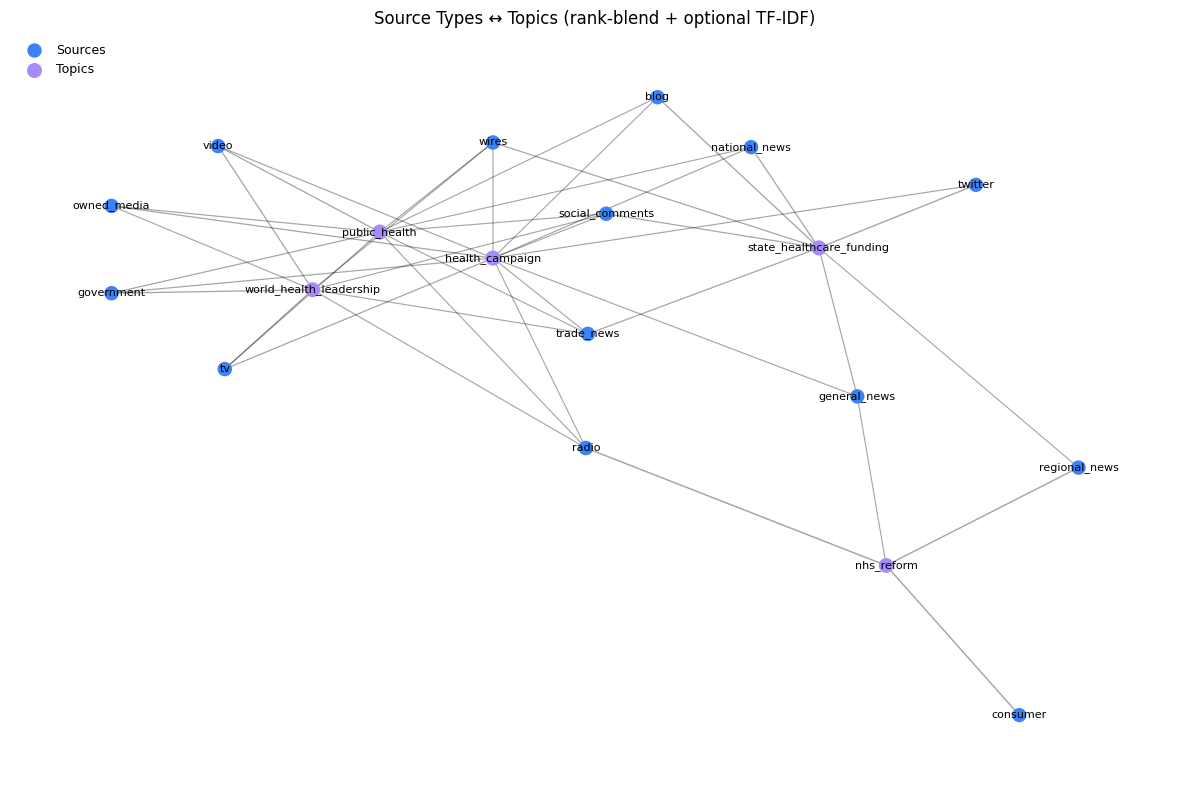

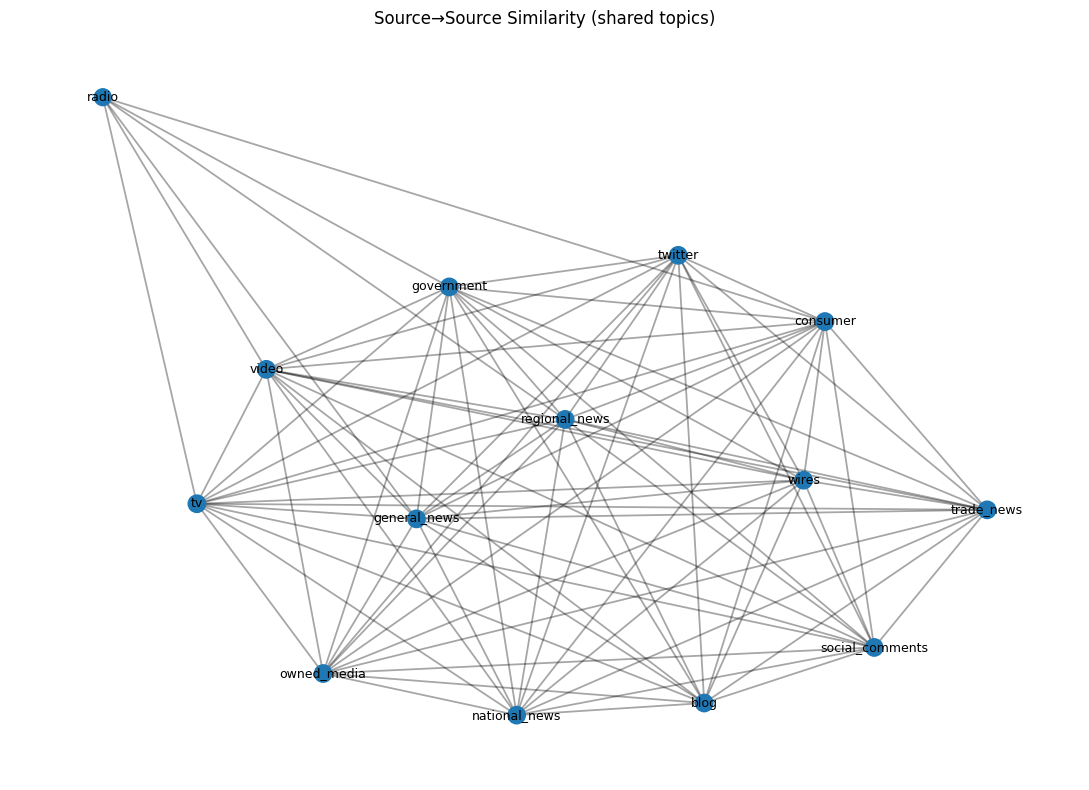

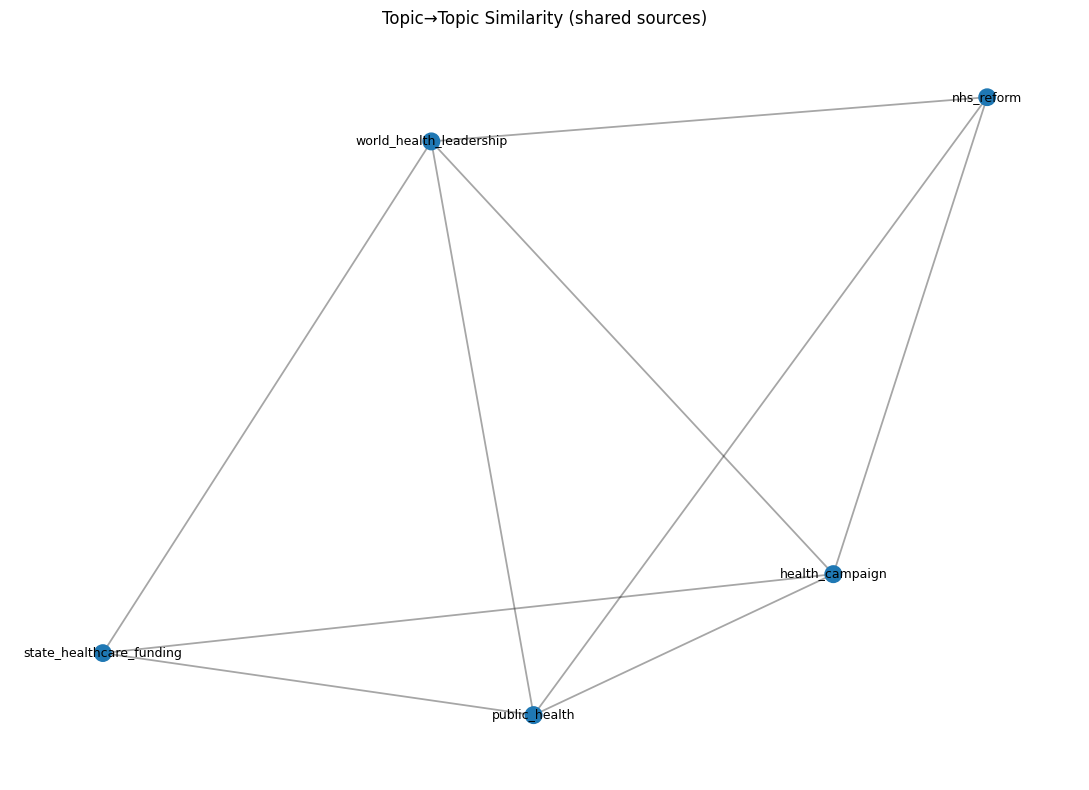

In [13]:
#4) Build + visualize + lists  — robust version with column fallback + clear errors
import numpy as np
import pandas as pd
import networkx as nx
try:
    # only needed if your visualize/project helpers use `nxb.*`
    from networkx.algorithms import bipartite as nxb  # safe if already imported
except Exception:
    pass

# --- Validate columns up front and auto-pick a valid source if needed ---
CANDIDATE_SOURCES = [
    "source_type",       # broad category (safe default in your schema)
    "publication_name",  # outlet
    "publisher_name",
    "source_feed_name",
    "channel_name",
    "feed_name",
]

def _suggest(msg, target, cols):
    from difflib import get_close_matches
    sugg = get_close_matches(target, list(cols), n=3)
    extra = f"\nDid you mean one of: {sugg}" if sugg else ""
    raise KeyError(msg + extra)

# Use the user-provided SOURCE_COL if it exists; otherwise pick the first valid candidate.
if SOURCE_COL not in DF.columns:
    # try to pick a good fallback automatically
    fallback = next((c for c in CANDIDATE_SOURCES if c in DF.columns), None)
    if fallback is None:
        _suggest(f"Missing source column '{SOURCE_COL}' and no fallback found.",
                 SOURCE_COL, DF.columns)
    else:
        print(f"[info] SOURCE_COL '{SOURCE_COL}' not found. Using fallback: '{fallback}'")
        SOURCE_COL = fallback

# Topic must exist (you set TOPIC_COL = 'tag_name' which is present in your schema)
if TOPIC_COL not in DF.columns:
    _suggest(f"Missing topic column '{TOPIC_COL}'.", TOPIC_COL, DF.columns)

# Weight-by columns must all exist
for c in (WEIGHT_BY if isinstance(WEIGHT_BY, list) else [WEIGHT_BY]):
    if c != "count" and c not in DF.columns:
        _suggest(f"Weight column '{c}' not found.", c, DF.columns)

# --- Build
B, agg, sources, topics = build_source_topic_bipartite(
    DF,
    source_col=SOURCE_COL,
    topic_col=TOPIC_COL,
    weight_by=WEIGHT_BY,
    weight_weights=WEIGHT_WEIGHTS,
    min_edge_weight=MIN_EDGE_WEIGHT,
    min_topics_per_source=MIN_TOPICS_PER_SOURCE,
    min_sources_per_topic=MIN_SOURCES_PER_TOPIC,
    use_tfidf=USE_TFIDF,
    use_sum_instead_of_mean=False
)

print("edges kept in agg:", len(agg))
print("sources:", len(sources), "topics:", len(topics))
display(agg.sort_values("weight", ascending=False).head(15))

# --- Auto-relax if everything was pruned
if len(agg) == 0 or len(sources) == 0 or len(topics) == 0:
    print("Nothing left after thresholds → relaxing filters...")
    B, agg, sources, topics = build_source_topic_bipartite(
        DF, SOURCE_COL, TOPIC_COL,
        weight_by=WEIGHT_BY, weight_weights=WEIGHT_WEIGHTS,
        min_edge_weight=0.0, min_topics_per_source=1, min_sources_per_topic=1,
        use_tfidf=False, use_sum_instead_of_mean=False
    )
    print("RELAXED → edges:", len(agg), "sources:", len(sources), "topics:", len(topics))

# --- Visuals
visualize_bipartite(
    B, sources, topics,
    title="Source Types ↔ Topics (rank-blend + optional TF-IDF)",
    label_sources_top=LABEL_SOURCES_TOP,
    label_topics_top=LABEL_TOPICS_TOP,
    edge_keep_pct=EDGE_KEEP_PCT_BIP
)

Gs = project_sources(B, sources, method="overlap")
visualize_projection(Gs, title="Source→Source Similarity (shared topics)", label_top=25, edge_keep_pct=EDGE_KEEP_PCT_PROJ)

Gt = project_topics(B, topics, method="overlap")
visualize_projection(Gt, title="Topic→Topic Similarity (shared sources)", label_top=25, edge_keep_pct=EDGE_KEEP_PCT_PROJ)

In [14]:
edge_table = agg.sort_values("weight", ascending=False).reset_index(drop=True)
display(edge_table.head(25))

,source_type,tag_name,weight
0,radio,nhs_reform,0.619525
1,consumer,nhs_reform,0.562622
2,regional_news,nhs_reform,0.549757
3,twitter,state_healthcare_funding,0.502776
4,blog,state_healthcare_funding,0.430138
5,government,world_health_leadership,0.402563
6,national_news,state_healthcare_funding,0.395868
7,video,public_health,0.385940
8,trade_news,state_healthcare_funding,0.382653
9,video,world_health_leadership,0.373591


In [15]:
### Top Topic per Source
def top_k_topics_per_source(agg: pd.DataFrame, source_col=SOURCE_COL, topic_col=TOPIC_COL, k=10) -> pd.DataFrame:
    if agg.empty: return agg
    return (agg.sort_values(["weight"], ascending=False)
              .groupby(source_col, group_keys=False)
              .head(k)
              .reset_index(drop=True))

display(top_k_topics_per_source(agg, k=8).head(30))

,source_type,tag_name,weight
0,radio,nhs_reform,0.619525
1,consumer,nhs_reform,0.562622
2,regional_news,nhs_reform,0.549757
3,twitter,state_healthcare_funding,0.502776
4,blog,state_healthcare_funding,0.430138
5,government,world_health_leadership,0.402563
6,national_news,state_healthcare_funding,0.395868
7,video,public_health,0.385940
8,trade_news,state_healthcare_funding,0.382653
9,video,world_health_leadership,0.373591


In [16]:
### Top Sources per Topic (ranking within each topic)
def top_k_sources_per_topic(agg: pd.DataFrame, source_col=SOURCE_COL, topic_col=TOPIC_COL, k=10) -> pd.DataFrame:
    if agg.empty: return agg
    return (agg.sort_values(["weight"], ascending=False)
              .groupby(topic_col, group_keys=False)
              .head(k)
              .reset_index(drop=True))

display(top_k_sources_per_topic(agg, k=8).head(30))

,source_type,tag_name,weight
0,radio,nhs_reform,0.619525
1,consumer,nhs_reform,0.562622
2,regional_news,nhs_reform,0.549757
3,twitter,state_healthcare_funding,0.502776
4,blog,state_healthcare_funding,0.430138
5,government,world_health_leadership,0.402563
6,national_news,state_healthcare_funding,0.395868
7,video,public_health,0.385940
8,trade_news,state_healthcare_funding,0.382653
9,video,world_health_leadership,0.373591


In [17]:
# Strength tables (weighted degree)
def _node_strength(G):
    return {n: sum(G[n][nbr].get("weight",1) for nbr in G.neighbors(n)) for n in G.nodes()}
if B.number_of_nodes() > 0:
    S = _node_strength(B)
    display(pd.Series({n:s for n,s in S.items() if n in sources}, name="strength")
              .sort_values(ascending=False).head(25).to_frame())
    display(pd.Series({n:s for n,s in S.items() if n in topics},  name="strength")
              .sort_values(ascending=False).head(25).to_frame())

,strength
regional_news,1.428467
consumer,1.425579
radio,1.398840
general_news,1.281870
twitter,1.209516
blog,1.186006
national_news,1.178517
trade_news,1.176946
wires,1.166198
social_comments,1.164804


,strength
health_campaign,3.979141
world_health_leadership,3.849752
public_health,3.797944
state_healthcare_funding,3.377661
nhs_reform,1.980939


In [18]:
### Source -> Source (From Visual Above)
pairs_src = (pd.DataFrame([(u, v, d.get("weight", 1)) for u, v, d in Gs.edges(data=True)],
                          columns=["source_u", "source_v", "weight"])
               .sort_values("weight", ascending=False))
display(pairs_src.head(25))

,source_u,source_v,weight
0,wires,regional_news,1.0
68,trade_news,general_news,1.0
66,trade_news,social_comments,1.0
65,trade_news,blog,1.0
64,trade_news,government,1.0
63,trade_news,national_news,1.0
62,twitter,owned_media,1.0
61,twitter,general_news,1.0
60,twitter,video,1.0
59,twitter,social_comments,1.0


In [19]:
### Topic -> Topic (From Visual)
pairs_topic = (pd.DataFrame([(u, v, d.get("weight", 1)) for u, v, d in Gt.edges(data=True)],
                            columns=["topic_u", "topic_v", "weight"])
                 .sort_values("weight", ascending=False))
display(pairs_topic.head(25))

,topic_u,topic_v,weight
0,nhs_reform,world_health_leadership,1.00
1,nhs_reform,public_health,1.00
3,nhs_reform,health_campaign,1.00
4,health_campaign,state_healthcare_funding,1.00
5,health_campaign,world_health_leadership,1.00
6,health_campaign,public_health,1.00
7,public_health,world_health_leadership,1.00
8,public_health,state_healthcare_funding,1.00
9,state_healthcare_funding,world_health_leadership,1.00
2,nhs_reform,state_healthcare_funding,0.75


In [ ]:
# === Influence Network: concise static plot (uses df_conv) ====================
# What this does (brief):
# - Takes your unified attribution table (df_conv) with columns:
#   kind, dimension, value, credit, credit_share, rating, rating_pct
# - Builds a directed graph: state/value  ->  <CONV> (edge weight = credit_share or credit)
# - Plots a concise static network:
#     color = dimension, shape = kind (● item, ▲ term),
#     node size ≈ credit_share, edge width ≈ weight,
#     labels only for nodes above a threshold to avoid clutter.

In [20]:
SINK_LABEL = "<CONV>"
DIMENSION_COLORS = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
]
KIND_MARKERS = {"item": "o", "term": "^"}  # circle, triangle

# ---- prep & helpers ----
def prep_attr_df_conv(df_conv: pd.DataFrame) -> pd.DataFrame:
    required = {"kind","dimension","value","credit","credit_share","rating","rating_pct"}
    missing = required - set(df_conv.columns)
    if missing:
        raise ValueError(f"df_conv missing required columns: {sorted(missing)}")
    out = df_conv.copy()
    out["kind"] = out["kind"].astype(str)
    out["dimension"] = out["dimension"].astype(str)
    out["value"] = out["value"].astype(str)
    for c in ("credit","credit_share","rating_pct"):
        out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0.0)
    out["rating"] = pd.to_numeric(out["rating"], errors="coerce").fillna(0).astype(int)
    return out

def filter_top_per_dimension(df_conv: pd.DataFrame, top_k: Optional[int] = 50, min_share: float = 0.0) -> pd.DataFrame:
    x = df_conv.copy()
    # filter by per-dimension share (credit_share) — classic behavior
    if min_share > 0:
        x = x[x["credit_share"] >= min_share]
    if top_k and top_k > 0:
        x = (
            x.sort_values(["dimension","credit_share"], ascending=[True, False])
             .groupby("dimension", as_index=False)
             .head(top_k)
        )
    return x.reset_index(drop=True)

def choose_labels_by_rank(G: nx.DiGraph, top_labels_per_dim: int = 10) -> dict:
    # rank by per-dimension credit_share stored on nodes
    by_dim = {}
    for n, d in G.nodes(data=True):
        if n == SINK_LABEL: 
            continue
        dim = d.get("dimension","other")
        by_dim.setdefault(dim, []).append((n, d.get("credit_share", 0.0)))
    labels = {}
    for dim, pairs in by_dim.items():
        pairs.sort(key=lambda t: t[1], reverse=True)
        for n,_ in pairs[:top_labels_per_dim]:
            labels[n] = n
    return labels

In [21]:
# -------------------- Attribution prep shim (drop-in) --------------------
import numpy as np
import pandas as pd

# ---- constants used by your plotting code
SINK_LABEL = "<CONV>"
DIMENSION_COLORS = [
    "#3b82f6", "#a78bfa", "#f59e0b", "#10b981", "#ef4444", "#8b5cf6",
    "#14b8a6", "#eab308", "#f97316", "#22c55e", "#ec4899", "#06b6d4"
]
KIND_MARKERS = {"item": "o", "term": "^", "sink": "s"}

def prep_attr_df_conv(df_conv: pd.DataFrame) -> pd.DataFrame:
    """
    Build the columns expected by build_graph_classic/draw_static_classic from your current df_conv.
    Assumptions (tweak as needed):
      - value := tag_name
      - dimension := 'person' if has_person else 'topic'
      - kind := 'item' for person-like values, 'term' otherwise
      - credit := vipr_weight for rows where is_conversion is True, else 0
      - credit_share := credit / sum(credit)
      - rating := rank-based 1..5 buckets from per-value conversion counts
      - rating_pct := per-value conversion count percentile [0,1]
    """
    required_source = {
        "tag_name", "has_person", "is_conversion", "vipr_weight"
    }
    missing_src = [c for c in required_source if c not in df_conv.columns]
    if missing_src:
        raise ValueError(
            f"prep_attr_df_conv needs these columns present first: {sorted(missing_src)}"
        )

    out = df_conv.copy()

    # 1) value / dimension / kind
    out["value"] = out["tag_name"].astype("string")

    out["dimension"] = pd.Series(
        np.where(out["has_person"].astype(bool), "person", "topic"),
        index=out.index,
        dtype="string"
    )

    out["kind"] = pd.Series(
        np.where(out["dimension"].eq("person"), "item", "term"),
        index=out.index,
        dtype="string"
    )

    # 2) credit (simple, interpretable): credit only on conversions, weighted by vipr_weight
    #    You can strengthen with circulation/sentiment if you like (see commented line).
    conv = out["is_conversion"].astype(bool)
    vw = pd.to_numeric(out["vipr_weight"], errors="coerce").fillna(0).clip(lower=0)
    out["credit"] = np.where(conv, vw, 0.0).astype(float)

    # Example alternative with circulation & sentiment amplification:
    # circ = pd.to_numeric(out["circulation_size"], errors="coerce").fillna(0)
    # sent = pd.to_numeric(out["sentiment_score"], errors="coerce").fillna(0)
    # out["credit"] = np.where(conv, (vw + 1.0) * (1.0 + np.log1p(circ)) * (1.0 + (sent > 0)), 0.0)

    # 3) credit_share by value
    grp_credit = out.groupby("value")["credit"].sum().rename("credit_sum")
    out = out.join(grp_credit, on="value")
    total_credit = float(grp_credit.sum())
    if total_credit <= 0:
        # guard: avoid divide-by-zero — give tiny uniform share to make the chart render
        nvals = grp_credit.shape[0] if grp_credit.shape[0] > 0 else 1
        out["credit_share"] = 1.0 / nvals
    else:
        out["credit_share"] = out["credit_sum"] / total_credit

    # 4) rating / rating_pct based on conversion counts per value
    conv_counts = out.groupby("value")["is_conversion"].sum().rename("conv_count")
    out = out.join(conv_counts, on="value")
    # Percentile rank [0,1]
    out["rating_pct"] = out["conv_count"].rank(pct=True).astype(float)
    # Map to 1..5 buckets (quintiles)
    out["rating"] = np.ceil(out["rating_pct"] * 5).clip(1, 5).astype(int)

    # Keep only what the graph builder expects + keys it groups by
    needed = [
        "value", "kind", "dimension",
        "credit", "credit_share",
        "rating", "rating_pct"
    ]
    return out[needed].copy()

def filter_top_per_dimension(attr_df: pd.DataFrame, top_k=50, min_share: float = 0.0) -> pd.DataFrame:
    """
    Keep top_k by credit_share within each dimension, and drop anything below min_share.
    """
    df = attr_df.copy()
    if min_share > 0:
        df = df[df["credit_share"] >= float(min_share)]
    # rank within dimension
    df["_r"] = df.groupby("dimension")["credit_share"].rank(method="first", ascending=False)
    return df[df["_r"] <= int(top_k)].drop(columns="_r")

def choose_labels_by_rank(G: "nx.Graph", top_labels_per_dim: int = 10) -> dict:
    """
    Choose label set: top-N per dimension by credit_share stored on nodes.
    """
    # pull node attributes to a DataFrame for ranking
    rows = []
    for n, d in G.nodes(data=True):
        if n == SINK_LABEL:
            continue
        rows.append({"node": n,
                     "dimension": d.get("dimension", "other"),
                     "credit_share": float(d.get("credit_share", 0.0))})
    if not rows:
        return {}
    tmp = pd.DataFrame(rows)
    tmp["_r"] = tmp.groupby("dimension")["credit_share"].rank(method="first", ascending=False)
    keep = set(tmp[tmp["_r"] <= int(top_labels_per_dim)]["node"].tolist())
    return {n: n for n in keep}
# -------------------- end shim --------------------

edges kept in agg: 56
sources: 14 topics: 5


,source_type,tag_name,weight
28,radio,nhs_reform,0.619525
5,consumer,nhs_reform,0.562622
32,regional_news,nhs_reform,0.549757
50,twitter,state_healthcare_funding,0.502776
2,blog,state_healthcare_funding,0.430138
17,government,world_health_leadership,0.402563
20,national_news,state_healthcare_funding,0.395868
53,video,public_health,0.385940
42,trade_news,state_healthcare_funding,0.382653
54,video,world_health_leadership,0.373591


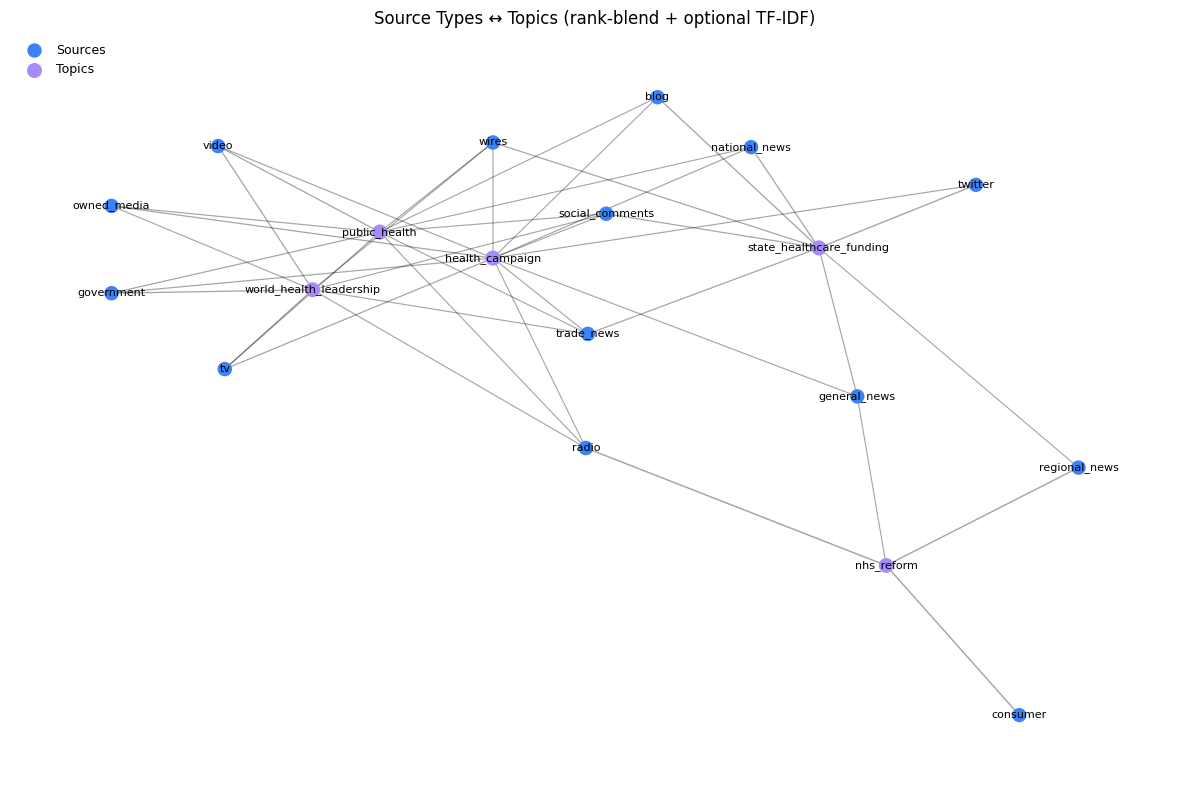

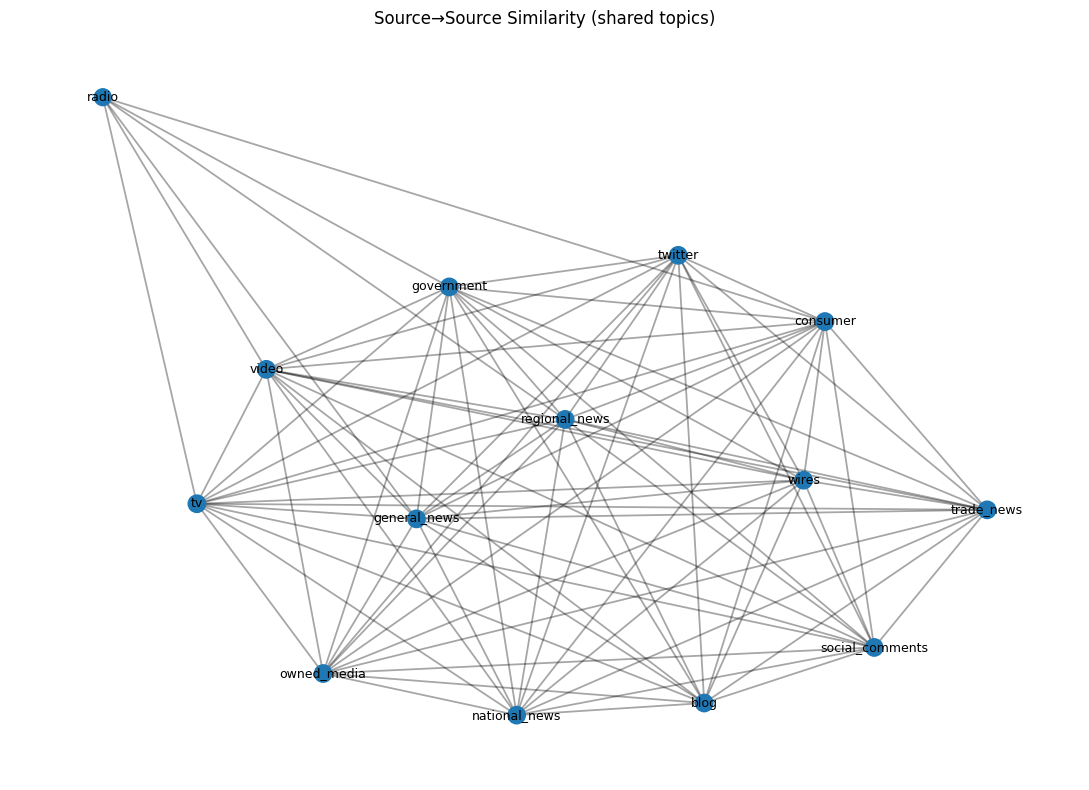

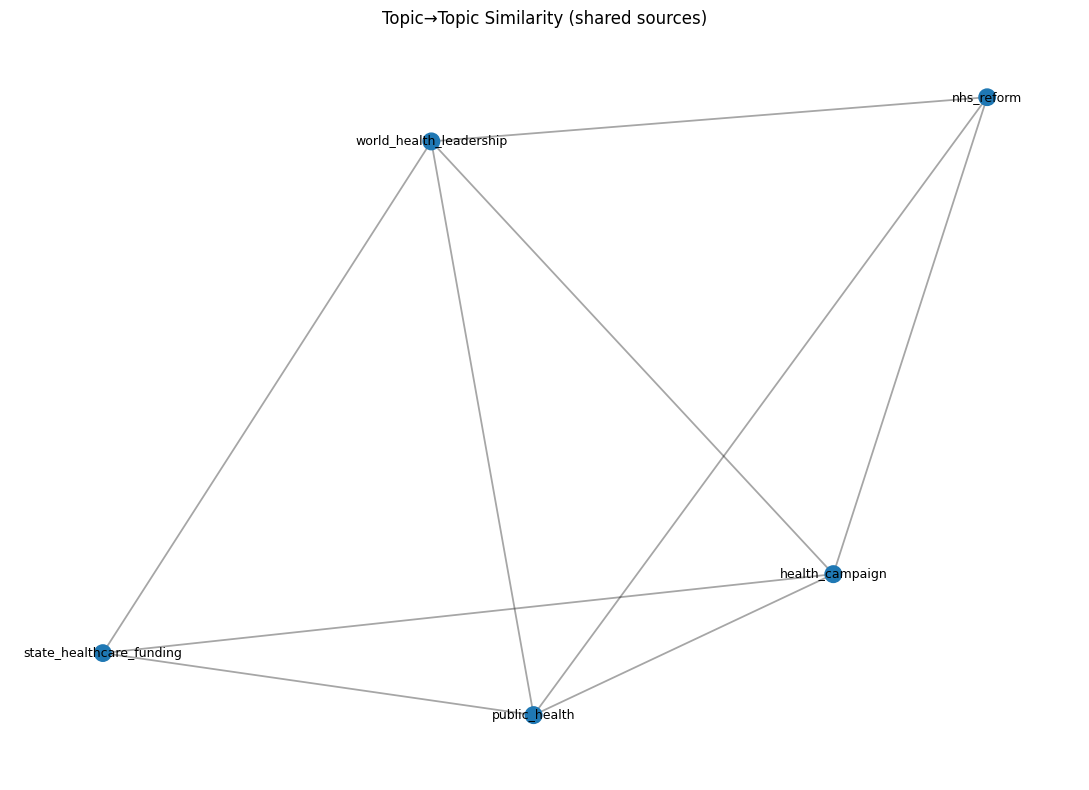

In [22]:
# --- CONFIG (choose ONE source column that exists) ---
SOURCE_COL = "source_type"          # or: "publication_name", "publisher_name", "source_feed_name", "channel_name", "feed_name"
TOPIC_COL  = "tag_name"

WEIGHT_BY = ["circulation_size", "vipr_weight", "hit_strength"]
WEIGHT_WEIGHTS = None
MIN_EDGE_WEIGHT = 0.2
MIN_TOPICS_PER_SOURCE = 2
MIN_SOURCES_PER_TOPIC = 2
USE_TFIDF = True

EDGE_KEEP_PCT_BIP  = 75
EDGE_KEEP_PCT_PROJ = 70
LABEL_SOURCES_TOP  = 25
LABEL_TOPICS_TOP   = 8

# --- Sanity checks + fallback if SOURCE_COL mistyped ---
from difflib import get_close_matches
CANDIDATE_SOURCES = ["source_type","publication_name","publisher_name","source_feed_name","channel_name","feed_name"]
if SOURCE_COL not in df_conv.columns:
    fb = next((c for c in CANDIDATE_SOURCES if c in df_conv.columns), None)
    if fb is None:
        raise KeyError(f"Bad SOURCE_COL='{SOURCE_COL}'. Did you mean: {get_close_matches(SOURCE_COL, df_conv.columns.tolist(), n=3)}")
    print(f"[info] SOURCE_COL '{SOURCE_COL}' not found → using '{fb}'")
    SOURCE_COL = fb
if TOPIC_COL not in df_conv.columns:
    raise KeyError(f"Bad TOPIC_COL='{TOPIC_COL}'. Did you mean: {get_close_matches(TOPIC_COL, df_conv.columns.tolist(), n=3)}")

# --- Build ---
B, agg, sources, topics = build_source_topic_bipartite(
    df_conv,
    source_col=SOURCE_COL,
    topic_col=TOPIC_COL,
    weight_by=WEIGHT_BY,
    weight_weights=WEIGHT_WEIGHTS,
    min_edge_weight=MIN_EDGE_WEIGHT,
    min_topics_per_source=MIN_TOPICS_PER_SOURCE,
    min_sources_per_topic=MIN_SOURCES_PER_TOPIC,
    use_tfidf=USE_TFIDF,
    use_sum_instead_of_mean=False
)
print("edges kept in agg:", len(agg))
print("sources:", len(sources), "topics:", len(topics))
display(agg.sort_values("weight", ascending=False).head(15))

# --- Relax if pruned away ---
if len(agg)==0 or len(sources)==0 or len(topics)==0:
    print("Nothing left after thresholds → relaxing filters…")
    B, agg, sources, topics = build_source_topic_bipartite(
        df_conv, SOURCE_COL, TOPIC_COL,
        weight_by=WEIGHT_BY, weight_weights=WEIGHT_WEIGHTS,
        min_edge_weight=0.0, min_topics_per_source=1, min_sources_per_topic=1,
        use_tfidf=False, use_sum_instead_of_mean=False
    )
    print("RELAXED → edges:", len(agg), "sources:", len(sources), "topics:", len(topics))

# --- Visuals ---
visualize_bipartite(
    B, sources, topics,
    title="Source Types ↔ Topics (rank-blend + optional TF-IDF)",
    label_sources_top=LABEL_SOURCES_TOP,
    label_topics_top=LABEL_TOPICS_TOP,
    edge_keep_pct=EDGE_KEEP_PCT_BIP
)

Gs = project_sources(B, sources, method="overlap")
visualize_projection(Gs, title="Source→Source Similarity (shared topics)", label_top=25, edge_keep_pct=EDGE_KEEP_PCT_PROJ)

Gt = project_topics(B, topics, method="overlap")
visualize_projection(Gt, title="Topic→Topic Similarity (shared sources)", label_top=25, edge_keep_pct=EDGE_KEEP_PCT_PROJ)

In [24]:
def _ensure_attr_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Accepts either:
      - an already-prepped attribution table (with value, kind, credit, credit_share), or
      - a raw df_conv-style table (with at least tag_name and vipr_weight, and
        optionally has_person and is_conversion).

    Returns a DataFrame with at least: ['value','kind','credit','credit_share'].
    """
    needed = {"value", "kind", "credit", "credit_share"}
    if needed.issubset(df.columns):
        out = df.copy()
        # Coerce numeric types safely
        out["credit"] = pd.to_numeric(out["credit"], errors="coerce").fillna(0.0)
        out["credit_share"] = pd.to_numeric(out["credit_share"], errors="coerce").fillna(0.0)
        out["value"] = out["value"].astype(str)
        out["kind"] = out["kind"].astype(str)
        return out

    # --- RAW MODE ---
    # We only truly require tag_name and vipr_weight.
    required_raw_min = {"tag_name", "vipr_weight"}
    missing_min = [c for c in required_raw_min if c not in df.columns]
    if missing_min:
        raise KeyError(f"Input is missing required raw columns: {missing_min}")

    out = df.copy()

    # If these flags are missing, create reasonable defaults
    if "has_person" not in out.columns:
        # For a pure terms table, we can safely treat everything as a 'term'
        out["has_person"] = False

    if "is_conversion" not in out.columns:
        # If df_conv is already filtered to conversion rows, this is fine
        out["is_conversion"] = True

    # value := topic string (adjust to publication_name, etc. if you want a different unit)
    out["value"] = out["tag_name"].astype(str)

    # kind := 'item' for person-like rows, 'term' otherwise
    out["kind"] = np.where(out["has_person"].astype(bool), "item", "term").astype(str)

    # credit := basic, interpretable: weight only on conversion rows
    vw = pd.to_numeric(out["vipr_weight"], errors="coerce").fillna(0).clip(lower=0).astype(float)
    conv = out["is_conversion"].astype(bool)
    out["credit"] = np.where(conv, vw, 0.0)

    # credit_share := per-value share within the current chunk
    credit_by_value = out.groupby("value")["credit"].sum().rename("credit_sum")
    out = out.join(credit_by_value, on="value")
    total_credit = float(credit_by_value.sum())
    if total_credit <= 0:
        # If there are no conversions/credit at all, give tiny uniform shares so tables render
        n = max(len(credit_by_value), 1)
        out["credit_share"] = 1.0 / n
    else:
        out["credit_share"] = out["credit_sum"] / total_credit

    return out[["value", "kind", "credit", "credit_share"]].copy()

In [ ]:
# ============================================================
# Publisher ↔ Term Content Network 
# ------------------------------------------------------------
# What this does (brief):
# - Builds a bipartite graph between publishers and their
#   articles' most influential term.
# - "Most influential term" per article is the matched term
#   whose global credit_share (from df_conv where kind=='term')
#   is highest among terms present in the article text.
# - Node size:
#     • publisher: number of matched articles (degree, weighted)
#     • term: total matched weight across publishers
# - Edge weight: sum of matched term weights between that
#   publisher and term (stronger association = thicker edge)
# - Visual: circles (publishers), triangles (terms), spring layout,
#   labels for top-N per type to keep it readable.

In [25]:
def _ensure_attr_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Accepts either:
      - an already-prepped attribution table (with value, kind, credit, credit_share), or
      - a raw df_conv-style table (with at least tag_name and vipr_weight, and
        optionally has_person and is_conversion).

    Returns a DataFrame with at least: ['value','kind','credit','credit_share'].
    """
    needed = {"value", "kind", "credit", "credit_share"}
    if needed.issubset(df.columns):
        out = df.copy()
        # Coerce numeric types safely
        out["credit"] = pd.to_numeric(out["credit"], errors="coerce").fillna(0.0)
        out["credit_share"] = pd.to_numeric(out["credit_share"], errors="coerce").fillna(0.0)
        out["value"] = out["value"].astype(str)
        out["kind"] = out["kind"].astype(str)
        return out

    # --- RAW MODE ---
    # We only truly require tag_name and vipr_weight.
    required_raw_min = {"tag_name", "vipr_weight"}
    missing_min = [c for c in required_raw_min if c not in df.columns]
    if missing_min:
        raise KeyError(f"Input is missing required raw columns: {missing_min}")

    out = df.copy()

    # If these flags are missing, create reasonable defaults
    if "has_person" not in out.columns:
        # For a pure terms table, we can safely treat everything as a 'term'
        out["has_person"] = False

    if "is_conversion" not in out.columns:
        # If df_conv is already filtered to conversion rows, this is fine
        out["is_conversion"] = True

    # value := topic string (adjust to publication_name, etc. if you want a different unit)
    out["value"] = out["tag_name"].astype(str)

    # kind := 'item' for person-like rows, 'term' otherwise
    out["kind"] = np.where(out["has_person"].astype(bool), "item", "term").astype(str)

    # credit := basic, interpretable: weight only on conversion rows
    vw = pd.to_numeric(out["vipr_weight"], errors="coerce").fillna(0).clip(lower=0).astype(float)
    conv = out["is_conversion"].astype(bool)
    out["credit"] = np.where(conv, vw, 0.0)

    # credit_share := per-value share within the current chunk
    credit_by_value = out.groupby("value")["credit"].sum().rename("credit_sum")
    out = out.join(credit_by_value, on="value")
    total_credit = float(credit_by_value.sum())
    if total_credit <= 0:
        # If there are no conversions/credit at all, give tiny uniform shares so tables render
        n = max(len(credit_by_value), 1)
        out["credit_share"] = 1.0 / n
    else:
        out["credit_share"] = out["credit_sum"] / total_credit

    return out[["value", "kind", "credit", "credit_share"]].copy()

In [26]:
# --------- Build edges: publisher ↔ best_term ----------
def build_publisher_term_edges(
    articles: pd.DataFrame,
    term_table: pd.DataFrame,
    term_limit: int = 500,
    min_term_weight: float = 0.0
) -> pd.DataFrame:
    """
    Returns edge table with columns: publisher, term, weight
    weight = sum of best_term weight across that publisher's matched articles.
    Only matches among top 'term_limit' terms by weight are considered for speed.
    """
    tt = term_table.head(term_limit).copy()
    ranked_terms = list(tt.itertuples(index=False, name=None))  # (term, weight)
    patterns = compile_term_patterns([t for t,_ in ranked_terms])

    edges = {}
    for _, r in articles.iterrows():
        txt = f"{r['headline']} {r['article_body']}"
        best_t, best_w = best_term_for_text(txt, ranked_terms, patterns)
        if best_t is None or best_w < min_term_weight:
            continue
        key = (r["publisher_name"], best_t)
        edges[key] = edges.get(key, 0.0) + best_w

    if not edges:
        return pd.DataFrame(columns=["publisher","term","weight"])

    pub, term, w = zip(*[(p,t,v) for (p,t),v in edges.items()])
    return pd.DataFrame({"publisher": pub, "term": term, "weight": w})

# --------- Graph builder & plotter ----------
def build_bipartite_graph(edges: pd.DataFrame) -> nx.Graph:
    """
    Build an undirected bipartite graph:
      set A = publishers (type='publisher')
      set B = terms      (type='term')
    Edge weights = aggregated association strength.
    """
    G = nx.Graph()
    for _, r in edges.iterrows():
        p, t, w = r["publisher"], r["term"], float(r["weight"])
        if p not in G: G.add_node(p, ntype="publisher")
        if t not in G: G.add_node(t, ntype="term")
        if w > 0:
            G.add_edge(p, t, weight=w)
    return G

def draw_publisher_term_network(
    G: nx.Graph,
    top_labels_per_type: int = 12,
    figsize=(14, 9)
):
    # size nodes by (weighted) degree
    def node_strength(n):
        return sum(G[n][nbr].get("weight", 0.0) for nbr in G.neighbors(n))

    strengths = {n: node_strength(n) for n in G.nodes()}
    max_strength = max(strengths.values()) if strengths else 1.0

    # scale sizes (nonlinear to spread)
    def scale(s): return max(80.0, (s / max_strength) ** 0.65 * 3000.0)
    sizes = [scale(strengths[n]) for n in G.nodes()]

    # colors & shapes by type
    color_map = {"publisher": "#1f77b4", "term": "#ff7f0e"}
    shape_map = {"publisher": "o", "term": "^"}
    node_types = nx.get_node_attributes(G, "ntype")
    node_colors = [color_map.get(node_types.get(n, "publisher"), "#7f7f7f") for n in G.nodes()]

    # layout (weighted for clarity)
    pos = nx.spring_layout(G, k=0.6, seed=42, weight="weight")

    plt.figure(figsize=figsize)

    # edges: thickness by weight (sqrt for contrast)
    widths = [max(0.5, (G[u][v].get("weight", 0.0) ** 0.5) * 6) for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.25)

    # draw nodes by type (for shapes)
    for t, marker in shape_map.items():
        nodes_t = [n for n in G.nodes() if node_types.get(n) == t]
        sizes_t = [sizes[list(G.nodes()).index(n)] for n in nodes_t]
        colors_t = [node_colors[list(G.nodes()).index(n)] for n in nodes_t]
        nx.draw_networkx_nodes(
            G, pos, nodelist=nodes_t, node_size=sizes_t, node_color=colors_t,
            node_shape=marker, linewidths=0.8, edgecolors="#333", alpha=0.95
        )

    # labels: top-N publishers and top-N terms by strength
    pubs = [n for n in G.nodes() if node_types.get(n) == "publisher"]
    terms = [n for n in G.nodes() if node_types.get(n) == "term"]
    pubs_top = sorted(pubs, key=lambda n: strengths[n], reverse=True)[:top_labels_per_type]
    terms_top = sorted(terms, key=lambda n: strengths[n], reverse=True)[:top_labels_per_type]
    labels = {n: n for n in pubs_top + terms_top}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

    # title + legend
    plt.title("Content Network: Publishers ↔ Highest-Impact Terms (per article)", fontsize=14, pad=10)
    subtitle = "Circle = publisher • Triangle = term • Node size ≈ weighted degree • Edge width ≈ association strength"
    plt.suptitle(subtitle, y=0.80, fontsize=9, color="#444")

    legend_handles = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=color_map["publisher"],
               markeredgecolor='#333', label='publisher', markersize=8),
        Line2D([0],[0], marker='^', color='w', markerfacecolor=color_map["term"],
               markeredgecolor='#333', label='term', markersize=8),
    ]
    plt.legend(handles=legend_handles, loc='upper left', frameon=True, title='Node type')

    plt.axis("off")
    plt.tight_layout()
    plt.show()